In [ ]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 87.7 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

In [ ]:
df = pd.read_csv('medical-charges.csv', index_col=0)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.90,0,1,southwest,"16,884.92"
1,18,1,33.77,1,0,southeast,"1,725.55"
2,28,1,33.00,3,0,southeast,"4,449.46"
3,33,1,22.70,0,0,northwest,"21,984.47"
4,32,1,28.88,0,0,northwest,"3,866.86"


In [ ]:
df.drop('region', axis=1)

,sex,bmi,children,smoker,charges
age,,,,,
19,female,27.90,0,yes,"16,884.92"
18,male,33.77,1,no,"1,725.55"
28,male,33.00,3,no,"4,449.46"
33,male,22.70,0,no,"21,984.47"
32,male,28.88,0,no,"3,866.86"
...,...,...,...,...,...
50,male,30.97,3,no,"10,600.55"
18,female,31.92,0,no,"2,205.98"
18,female,36.85,0,no,"1,629.83"


In [ ]:
df.duplicated().sum()
#data.drop_duplicates(inplace=True)

np.int64(1)

In [ ]:
df.isna().sum()

,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


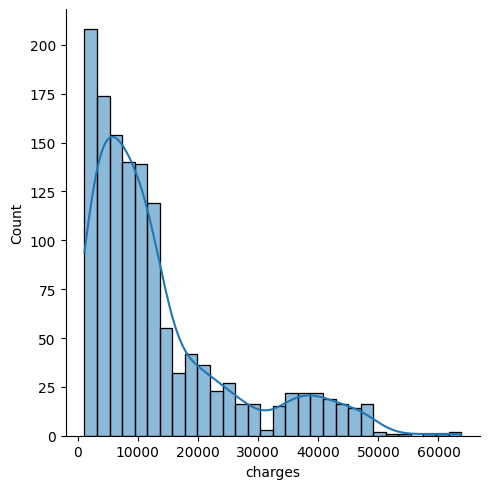

In [ ]:
fig = sns.displot(data=df, x='charges', kde=True)

In [ ]:
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

In [ ]:
df = df.reset_index()

In [ ]:
X = df[['age','sex','children','smoker','bmi']]
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linearReg = LinearRegression()
linearReg.fit(X_train, y_train)

LinearRegression()

In [ ]:
linearReg.score(X_test, y_test)

0.7811302113434095

In [ ]:
predicted_values = linearReg.predict(X_train)
residuals = y_train - predicted_values

<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-2753017292.py:5: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Prediced charges 000s $\hat y _i$', fontsize=14)


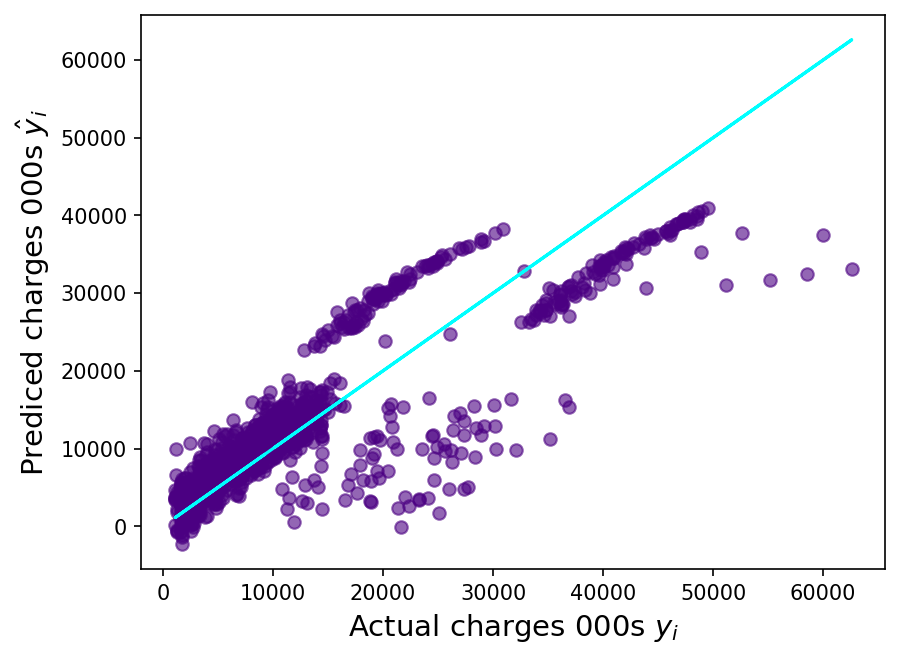

In [ ]:
fig = plt.figure(dpi=150)
plt.scatter(y_train, predicted_values, c='indigo', alpha=0.6)
plt.plot(y_train, y_train, color='cyan')
plt.xlabel('Actual charges 000s $y _i$', fontsize=14)
plt.ylabel('Prediced charges 000s $\hat y _i$', fontsize=14)
plt.show()


<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-856551484.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Predicted Charges $\hat y _i$', fontsize=14)


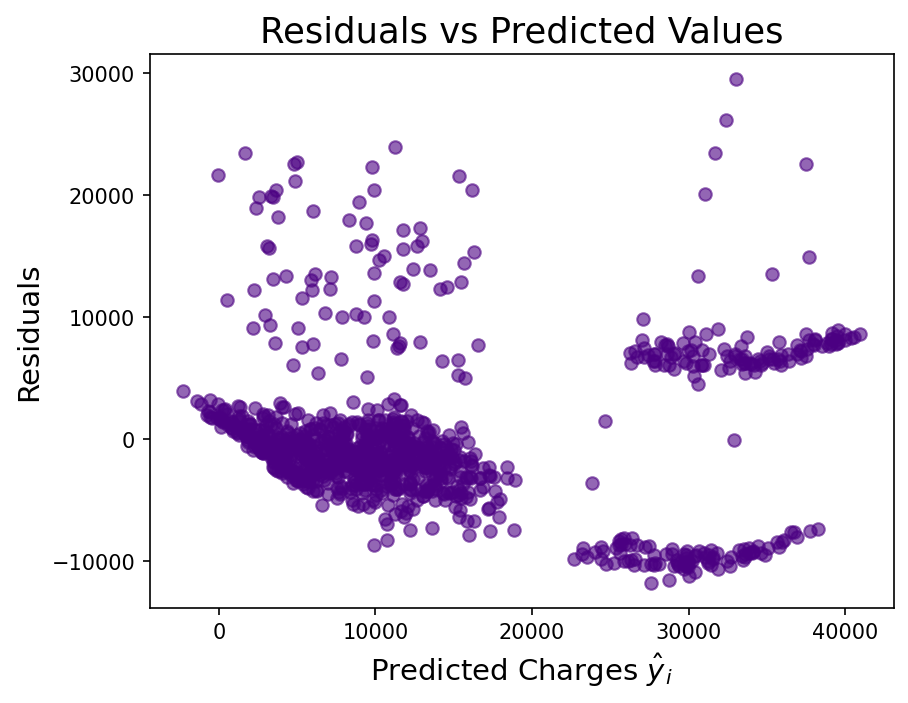

In [ ]:
fig = plt.figure(dpi=150)
plt.scatter(predicted_values, residuals, c='indigo', alpha=0.6)
plt.title('Residuals vs Predicted Values', fontsize=17)
plt.xlabel('Predicted Charges $\hat y _i$', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.show()

In [ ]:
test_data = pd.DataFrame({
'age': [17],
'sex': [1],
'children': [0],
'smoker': [0],
'bmi': [24]
})

In [ ]:
predicted_charges = linearReg.predict(test_data)
print(f'Predicted Medical Charge: ${np.exp(predicted_charges[0]):.2f}')

Predicted Medical Charge: $2475.07


In [ ]:
X = df[['age','sex','children','smoker','bmi']]
y = np.log(df['charges'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linearReg = LinearRegression()
linearReg.fit(X_train, y_train)

LinearRegression()

In [ ]:
linearReg.score(X_test, y_test)

0.7982703088326142